# Model Analysis Histórico Chat

---

## Objetivo

O objetivo desse notebook é realizar a análise final do modelo criado e garantir a melhor forma de seu uso real, suas fraquezas e seus pontos fortes.

---

## Código

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from scipy import sparse
import joblib

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


In [2]:
X_test = sparse.load_npz(
    "../../artifacts/analysis/X_test_no_clusters.npz"
)

y_te_enc = np.load(
    "../../artifacts/analysis/y_test.npy"
)

le = joblib.load(
    "../../artifacts/models/label_encoder.joblib"
)

print("X_test:", X_test.shape)
print("y_test:", y_te_enc.shape)
print("Classes:", len(le.classes_))

X_test: (3949, 100404)
y_test: (3949,)
Classes: 13


In [3]:
class SparseDataset(Dataset):
    def __init__(self, X_sparse, y_encoded):
        self.X_sparse = X_sparse.tocsr()
        self.y = torch.tensor(y_encoded, dtype=torch.long)

    def __len__(self):
        return self.X_sparse.shape[0]

    def __getitem__(self, idx):
        x_sample = self.X_sparse[idx].toarray().squeeze(0)

        return (
            torch.tensor(x_sample, dtype=torch.float32),
            self.y[idx]
        )

class SparseMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.net(x)

In [5]:
model = SparseMLP(
    input_dim=X_test.shape[1],
    num_classes=len(le.classes_)
).to(device)

model.load_state_dict(
    torch.load(
        "../../artifacts/models/scia_mlp_no_clusters.pt",
        map_location=device
    )
)

model.eval()

SparseMLP(
  (net): Sequential(
    (0): Linear(in_features=100404, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=13, bias=True)
  )
)

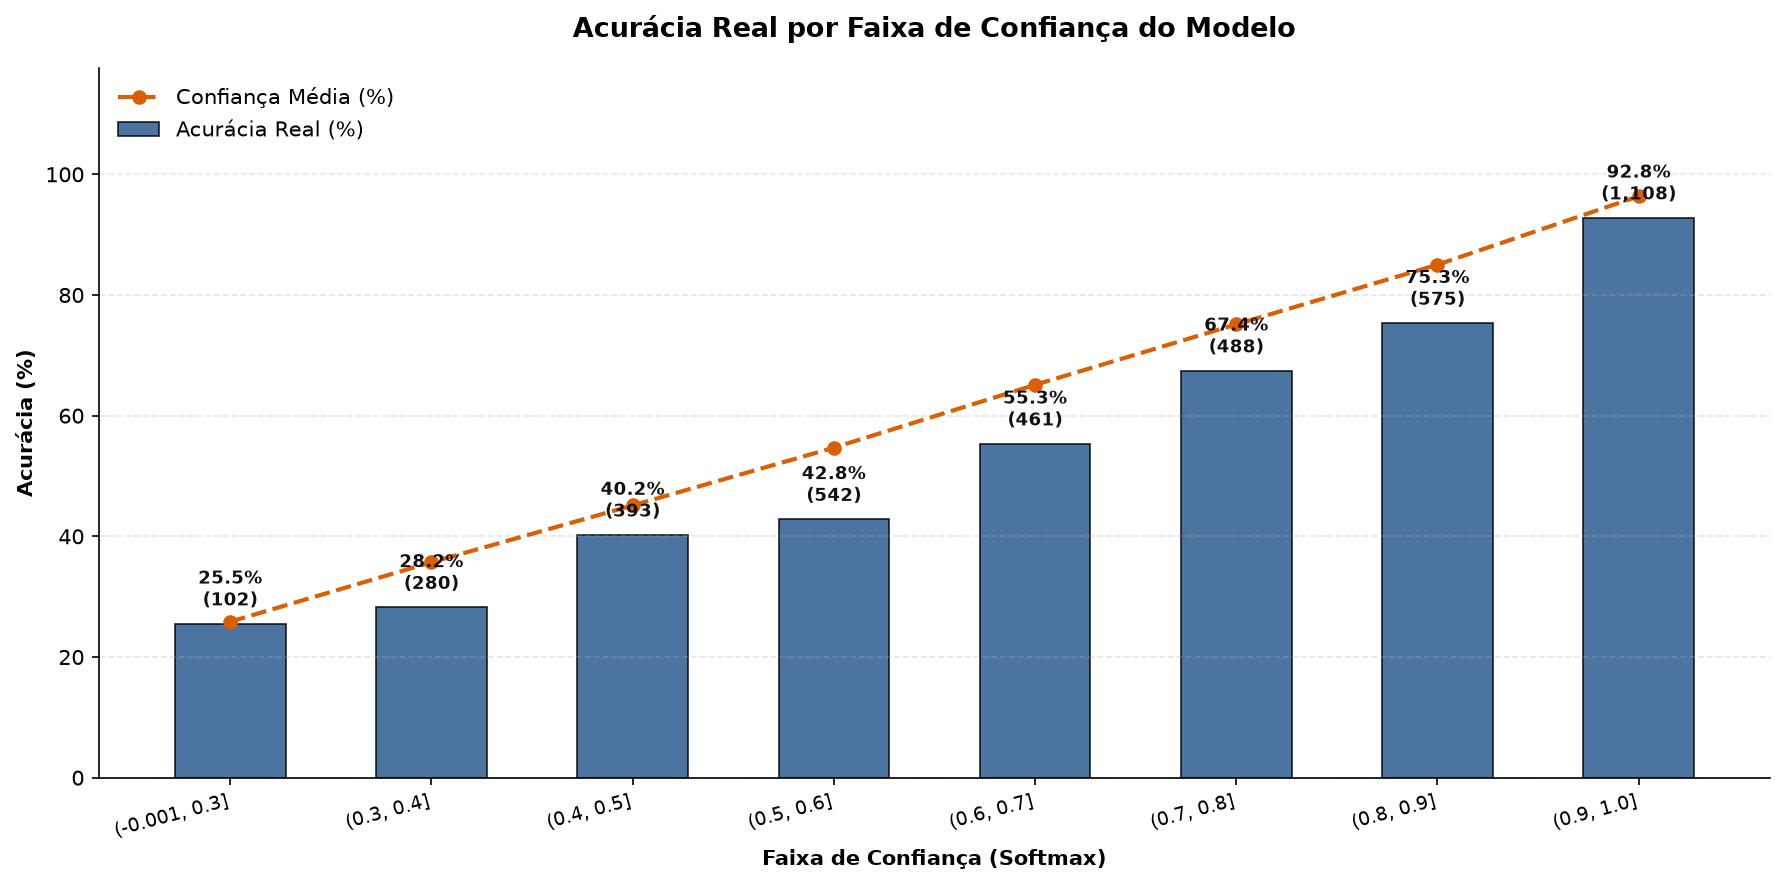

In [7]:
test_dataset = SparseDataset(X_test, y_te_enc)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False
)

all_proba = []

with torch.no_grad():
    for inputs, _ in test_loader:
        
        inputs = inputs.to(device)
        
        outputs = model(inputs)
        
        proba = torch.softmax(outputs, dim=1)
        
        all_proba.append(
            proba.cpu().numpy()
        )

proba_test = np.vstack(all_proba)
confianca = proba_test.max(axis=1)
pred_proba = proba_test.argmax(axis=1)
acertou = pred_proba == y_te_enc

df_confianca = pd.DataFrame({
    "real": le.inverse_transform(y_te_enc),
    "predito": le.inverse_transform(pred_proba),
    "confianca": confianca,
    "acertou": acertou
})

bins = [0.0, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

df_confianca["faixa_confianca"] = pd.cut(
    df_confianca["confianca"],
    bins=bins,
    include_lowest=True
)

analise_confianca = (
    df_confianca
    .groupby("faixa_confianca", observed=False)
    .agg(
        quantidade=("acertou", "size"),
        acuracia=("acertou", "mean"),
        confianca_media=("confianca", "mean")
    )
)

analise_confianca["acuracia"] *= 100
df_plot = analise_confianca.reset_index().copy()
df_plot["faixa_str"] = df_plot["faixa_confianca"].astype(str)

fig, ax1 = plt.subplots(figsize=(12, 6), dpi=150)

bars = ax1.bar(
    df_plot["faixa_str"],
    df_plot["acuracia"],
    color="#2b5c8f",
    edgecolor="black",
    linewidth=0.8,
    alpha=0.85,
    width=0.55,
    label="Acurácia Real (%)",
)

for bar, row in zip(bars, df_plot.itertuples()):
    height = bar.get_height()
    qtd = row.quantidade
    if qtd > 0:
        ax1.annotate(
            f"{height:.1f}%\n({qtd:,})",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 6),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8.5,
            fontweight="bold",
            color="#111111",
        )

conf_percent = df_plot["confianca_media"] * 100
ax1.plot(
    df_plot["faixa_str"],
    conf_percent,
    color="#d95f02",
    marker="o",
    linewidth=2,
    linestyle="--",
    label="Confiança Média (%)",
)

ax1.set_title(
    "Acurácia Real por Faixa de Confiança do Modelo",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
ax1.set_xlabel("Faixa de Confiança (Softmax)", fontsize=10, fontweight="bold")
ax1.set_ylabel("Acurácia (%)", fontsize=10, fontweight="bold")

max_y = max(df_plot["acuracia"].max(), conf_percent.max())
ax1.set_ylim(0, max_y * 1.22)

plt.xticks(rotation=15, ha="right", fontsize=9)

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.grid(axis="y", linestyle="--", alpha=0.3)

ax1.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="none")

plt.tight_layout()
plt.show()

In [9]:
df_test = pd.read_parquet("../../dados/processed/test.parquet")

df_analise_msg = df_test.copy()
df_analise_msg["membro_predito"] = df_confianca["predito"].values
df_analise_msg["confianca"] = df_confianca["confianca"].values
df_analise_msg["acertou"] = df_confianca["acertou"].values
df_analise_msg["faixa_confianca"] = df_confianca["faixa_confianca"].values

n_amostras = 20

amostras_lista = []
for faixa, group in df_analise_msg.groupby(
    "faixa_confianca", observed=False
):
    if len(group) > 0:
        qtd = min(len(group), n_amostras)
        sample_group = group.sample(n=qtd, random_state=42)
        amostras_lista.append(sample_group)

amostras_por_faixa = pd.concat(amostras_lista, axis=0)

colunas_exibicao = [
    "mensagem",
    "membro",
    "membro_predito",
    "confianca",
    "acertou",
]

for faixa, group in amostras_por_faixa.groupby(
    "faixa_confianca", observed=False
):
    print("\n" + "=" * 90)
    print(
        f" FAIXA DE CONFIANÇA: {faixa} | TOTAL EXIBIDO: {len(group)} MENSAGENS"
    )
    print("=" * 90)

    df_display = group[colunas_exibicao].copy()
    df_display["confianca"] = df_display["confianca"].apply(
        lambda x: f"{x*100:.2f}%"
    )

    display(df_display)


 FAIXA DE CONFIANÇA: (-0.001, 0.3] | TOTAL EXIBIDO: 20 MENSAGENS


,mensagem,membro,membro_predito,confianca,acertou
1388,"mas as de pista ganha 140 no dia, manhã e tard...",Guido,Guido,26.73%,True
2795,"uma partida, de futeboool vou tomar banho e ja...",Luiz,Luquete,24.41%,False
2651,oq vcs fariam se chegassem na academia e estiv...,Sr. Quick Açaí,Jão,25.00%,False
2127,nem é álcool é só o acompanhamento maioria dos...,Yuras,Caio,27.63%,False
1968,ansioso pra essa resenha sim nem toquei 2x na ...,Sr. Quick Açaí,André,26.50%,False
1885,qual a diferença qdo tipo tem aquele s de inte...,Arthur,Cauã,22.68%,False
3532,eu sim no meio cara funciona melhor,André,Jão,25.22%,False
2068,é @luquete recebi informações da amanda aq the...,Guido,André,28.31%,False
448,= festudo festeiro ou fez tudo bom dia sc agua...,Guido,Sr. Quick Açaí,22.44%,False
111,porção até sushi mano só não considero oq come...,Yuras,Luiz,28.79%,False



 FAIXA DE CONFIANÇA: (0.3, 0.4] | TOTAL EXIBIDO: 20 MENSAGENS


,mensagem,membro,membro_predito,confianca,acertou
514,brotem absurdo esse mlk ser banco absurdo.,Peter Lee,Peter Lee,39.12%,True
1579,martin luther king? kkkkkkkkkkkkkkkkkkkkkkkkkk...,Luiz,Luiz,33.32%,True
3399,só vem pra ufes vc aqui a gente vê certinho ma...,Luiz,Luquete,39.27%,False
3659,recadastro do cartão normal é o primeiro que a...,Luquete,Luquete,39.14%,True
2320,come fazendo careta? kkkkkkkkkkkkkkkkkkkkkkkkk...,Ítalo,Você,33.20%,False
114,aguardando por essa . essa ação pode levar alg...,Luquete,Luquete,38.47%,True
2243,ele passe a conseguir lançar de forma orgânica...,Jão,Luquete,38.84%,False
2899,caio virou eunuco? vou no sheiks fodase lama m...,Cauã,André,35.48%,False
2235,pqp o cara não aguenta o internacional mas vai...,Luiz,Luquete,30.60%,False
2331,desconfirmar trabalhar amanhã cedo amassou man...,Jão,Jão,39.85%,True



 FAIXA DE CONFIANÇA: (0.4, 0.5] | TOTAL EXIBIDO: 20 MENSAGENS


...

,mensagem,membro,membro_predito,confianca,acertou
672,"muito sim, é pertinho e o moxuara não é tão ru...",Luiz,Luiz,77.14%,True
2131,tô saindo de casa vou passar no kauã e dps aí ...,Yuras,Luiz,74.12%,False
3583,escócia? porra de escócia ja foi isso só jogo ...,Você,Você,70.80%,True
717,você acabando com o sonho do menor de portar g...,Peter Lee,Caio,78.56%,False
3251,uns 900 se não for mobiliado ou num lugar mais...,Yuras,Yuras,75.95%,True
3877,sim tem um site maravilhoso i love pdf ele faz...,Luquete,Luquete,79.68%,True
1727,eu te perdoo se vc der uma suckada ele nem foi...,Você,Cauã,76.92%,False
603,< > onde tá louco luiz é louco e a culpa é minha,Jão,Jão,78.59%,True
773,o quick é o pior agente duplo q ja existiu man...,Você,Você,79.21%,True
2565,os cara olha tudo conheço o mano eu tentei faz...,Ítalo,Você,79.32%,False



 FAIXA DE CONFIANÇA: (0.8, 0.9] | TOTAL EXIBIDO: 20 MENSAGENS


,mensagem,membro,membro_predito,confianca,acertou
916,calma mano eu tô rindo aqjin aqui respeita o b...,Luquete,Luquete,83.97%,True
695,sério? rápido quanto? pô tmnc kkkkkk daora tá ...,Yuras,Yuras,86.16%,True
1568,alguém inventa a opção todos menos eu por favo...,Luquete,Luquete,81.93%,True
2667,"italo e luiz vão se ninguém tiver, eu levo tem...",Caio,Caio,81.23%,True
1694,me ensina a configurar assim? civil? passa aq ...,Cauã,Cauã,85.65%,True
1078,tu ta se esforçando to vou ent vou então,Jão,Jão,81.27%,True
1441,não tô nem zuando < de album> < > < > < de >,Luiz,Luquete,89.37%,False
184,meu pc deu pau fi porra vei namoral acho que o...,Yuras,Yuras,80.38%,True
496,caraio que rolê é esse aí são fora coe fiz est...,Yuras,Yuras,85.62%,True
941,roteia o 4g < > quem vai assistir invencível c...,Caio,Caio,83.41%,True



 FAIXA DE CONFIANÇA: (0.9, 1.0] | TOTAL EXIBIDO: 20 MENSAGENS


,mensagem,membro,membro_predito,confianca,acertou
2111,@yuras foi vc? @caio @guido homem aranha amanh...,Luiz,Luiz,97.03%,True
2528,"tipo, vc e ele tem a mesma opinião e tudo né e...",Luiz,Luiz,92.22%,True
180,< de > slk @jão fabiano de atletismo professor...,Guido,Guido,99.57%,True
2265,[encaminhada] < > reclamômetro: luiz: 4 lucas:...,Caio,Caio,99.91%,True
2208,é q a outra entrada tá fechada sla aí falei q ...,Guido,Guido,99.83%,True
2107,n tem b.o n to falando q é ruim nem nada do ti...,Jão,Jão,97.59%,True
1758,a gente só tem var mesmo kkkkkkkkkkkkkkkkkkkkk...,André,André,97.22%,True
293,ela falou a palavra consultoria tributária mai...,Luquete,Luquete,91.38%,True
2195,dia da pizza hj galera mano tá ótimo po ? mas ...,Peter Lee,Peter Lee,99.20%,True
1177,a gnt teve duas chances de gol claras pra mata...,Jão,Jão,96.58%,True


/tmp/ipykernel_96639/2669311321.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


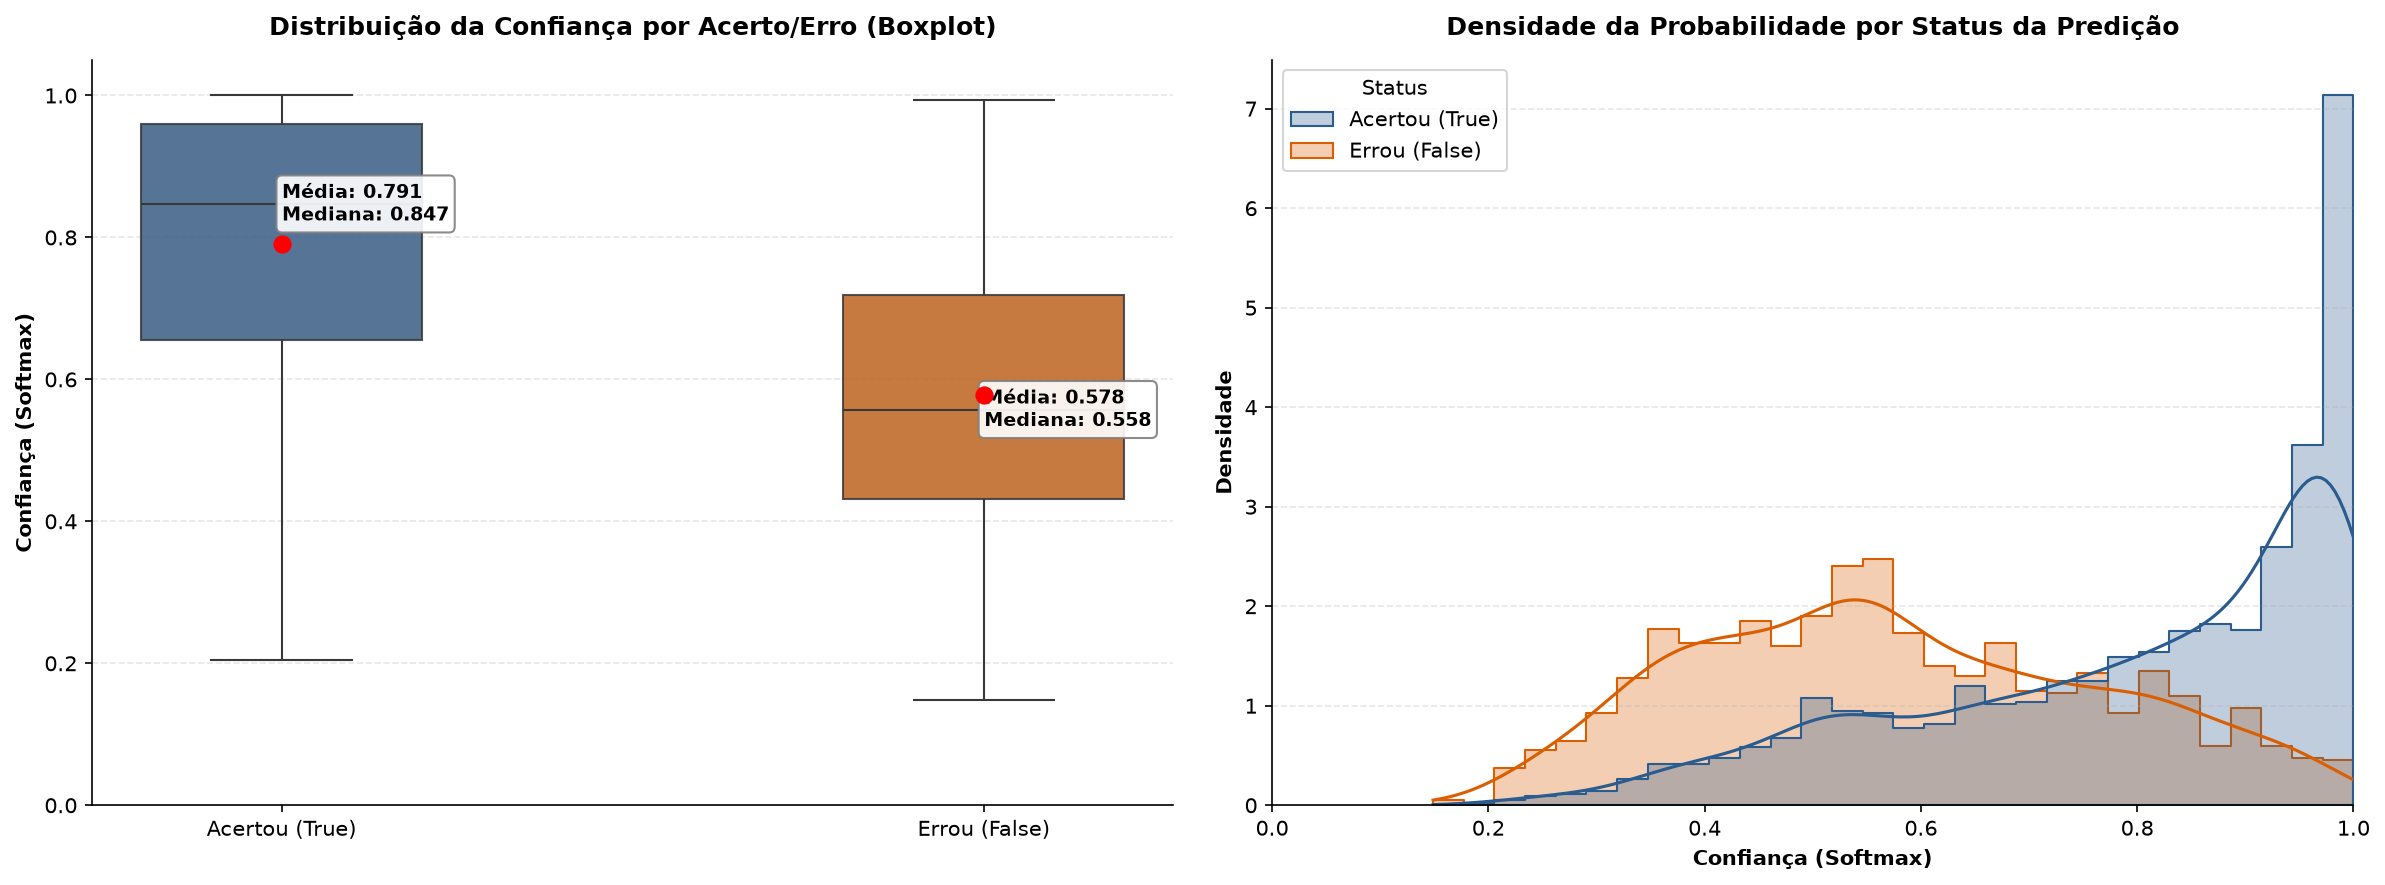

In [10]:
import seaborn as sns

df_confianca["Status"] = df_confianca["acertou"].map(
    {True: "Acertou (True)", False: "Errou (False)"}
)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), dpi=150)

palette = {"Acertou (True)": "#2b5c8f", "Errou (False)": "#d95f02"}

sns.boxplot(
    data=df_confianca,
    x="Status",
    y="confianca",
    palette=palette,
    ax=ax1,
    width=0.4,
    fliersize=2,
    boxprops=dict(alpha=0.85),
)

# Adicionar pontos da média visualmente no boxplot
stats = df_confianca.groupby("Status")["confianca"].agg(["mean", "median"])
for i, (status, row) in enumerate(stats.iterrows()):
    ax1.scatter(
        i,
        row["mean"],
        color="red",
        s=60,
        zorder=5,
        label="Média" if i == 0 else "",
    )
    ax1.annotate(
        f"Média: {row['mean']:.3f}\nMediana: {row['median']:.3f}",
        xy=(i, row["median"]),
        xytext=(0.28, 0),
        textcoords="offset points",
        va="center",
        fontsize=9,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9
        ),
    )

ax1.set_title(
    "Distribuição da Confiança por Acerto/Erro (Boxplot)",
    fontsize=12,
    fontweight="bold",
    pad=12,
)
ax1.set_xlabel("")
ax1.set_ylabel("Confiança (Softmax)", fontsize=10, fontweight="bold")
ax1.set_ylim(0, 1.05)

sns.histplot(
    data=df_confianca,
    x="confianca",
    hue="Status",
    element="step",
    stat="density",
    common_norm=False,
    bins=30,
    palette=palette,
    kde=True,
    ax=ax2,
    alpha=0.3,
)

ax2.set_title(
    "Densidade da Probabilidade por Status da Predição",
    fontsize=12,
    fontweight="bold",
    pad=12,
)
ax2.set_xlabel("Confiança (Softmax)", fontsize=10, fontweight="bold")
ax2.set_ylabel("Densidade", fontsize=10, fontweight="bold")
ax2.set_xlim(0, 1)

for ax in (ax1, ax2):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

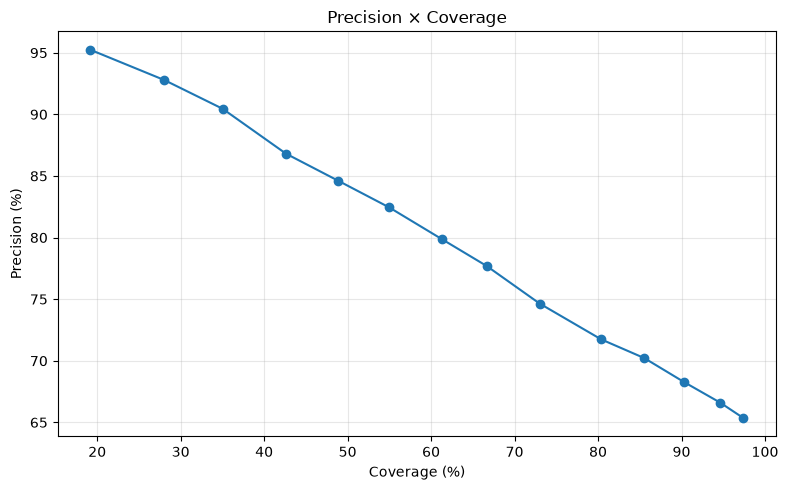

In [11]:
thresholds = np.arange(0.30, 1.00, 0.05)

resultados_threshold = []

for threshold in thresholds:
    
    selecionados = confianca >= threshold
    
    coverage = selecionados.mean()
    
    if selecionados.sum() > 0:
        precision = acertou[selecionados].mean()
    else:
        precision = np.nan
    
    resultados_threshold.append({
        "threshold": threshold,
        "precision": precision,
        "coverage": coverage,
        "mensagens": selecionados.sum()
    })

df_threshold = pd.DataFrame(resultados_threshold)

df_threshold["precision"] *= 100
df_threshold["coverage"] *= 100

plt.figure(figsize=(8, 5))

plt.plot(
    df_threshold["coverage"],
    df_threshold["precision"],
    marker="o"
)

plt.xlabel("Coverage (%)")
plt.ylabel("Precision (%)")
plt.title("Precision × Coverage")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

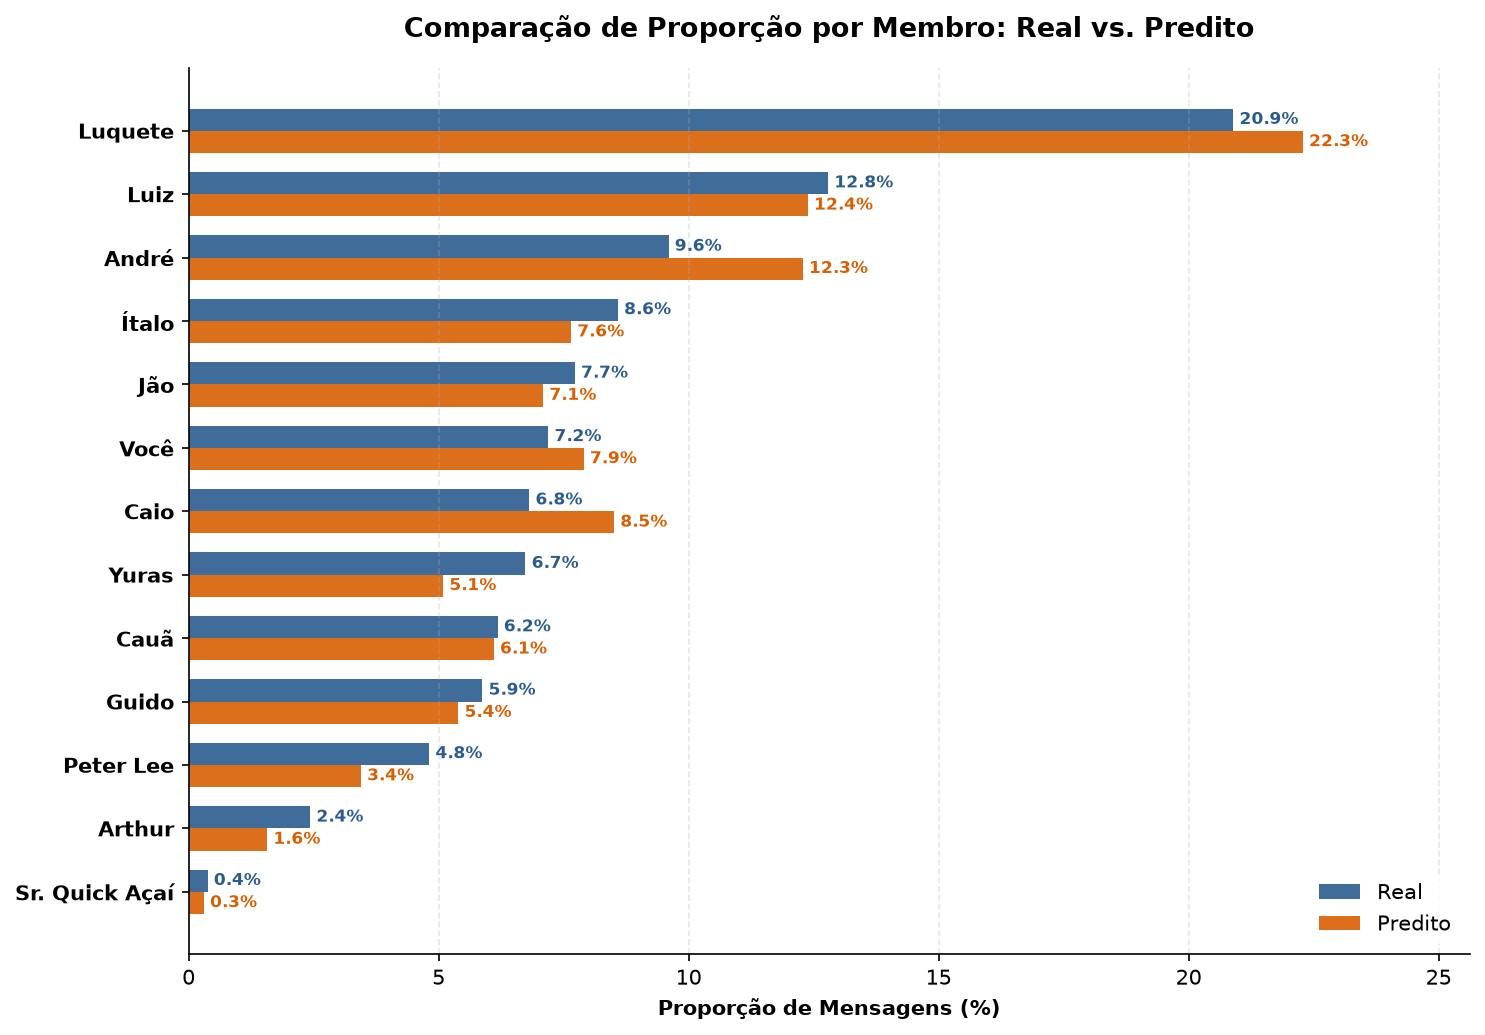

In [12]:
real_dist = (
    pd.Series(le.inverse_transform(y_te_enc))
    .value_counts(normalize=True)
    .rename("real")
)

pred_dist = (
    pd.Series(le.inverse_transform(pred_proba))
    .value_counts(normalize=True)
    .rename("predito")
)

comparacao_dist = pd.concat(
    [real_dist, pred_dist],
    axis=1
).fillna(0)

comparacao_dist["diferenca"] = (
    comparacao_dist["predito"] -
    comparacao_dist["real"]
)

comparacao_dist.sort_values(
    "diferenca",
    ascending=False
)
df_plot = comparacao_dist.sort_values("real", ascending=True)

y = np.arange(len(df_plot))
height = 0.35  

fig, ax = plt.subplots(figsize=(10, 7), dpi=150)

rects1 = ax.barh(
    y + height / 2,
    df_plot["real"] * 100,
    height,
    label="Real",
    color="#2b5c8f",
    alpha=0.9,
)
rects2 = ax.barh(
    y - height / 2,
    df_plot["predito"] * 100,
    height,
    label="Predito",
    color="#d95f02",
    alpha=0.9,
)

for rect in rects1:
    width = rect.get_width()
    ax.annotate(
        f"{width:.1f}%",
        xy=(width, rect.get_y() + rect.get_height() / 2),
        xytext=(3, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=8,
        color="#2b5c8f",
        fontweight="bold",
    )

for rect in rects2:
    width = rect.get_width()
    ax.annotate(
        f"{width:.1f}%",
        xy=(width, rect.get_y() + rect.get_height() / 2),
        xytext=(3, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=8,
        color="#d95f02",
        fontweight="bold",
    )

ax.set_title(
    "Comparação de Proporção por Membro: Real vs. Predito",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Proporção de Mensagens (%)", fontsize=10, fontweight="bold")
ax.set_yticks(y)
ax.set_yticklabels(df_plot.index, fontsize=10, fontweight="bold")

max_val = max(df_plot["real"].max(), df_plot["predito"].max()) * 100
ax.set_xlim(0, max_val * 1.15)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.3)

ax.legend(
    loc="lower right",
    frameon=True,
    facecolor="white",
    edgecolor="none",
    fontsize=10,
)

plt.tight_layout()
plt.show()


# Escolha do Threshold na Perspectiva da Regra de Negócio

Partindo da premissa de que o SCIA atua como um Fiscal Absoluto de Estilo, o objetivo do modelo não é simplesmente maximizar o número de previsões realizadas. O bot deve intervir apenas quando possuir evidência suficiente para sustentar sua acusação.

Nesse contexto, o threshold de confiança não representa apenas uma configuração estatística do classificador. Ele funciona como um controle de convicção do bot, determinando em quais situações o SCIA considera sua própria previsão suficientemente forte para se manifestar.

A V2 apresenta uma característica particularmente favorável para esse uso: a confiança do modelo possui forte relação com a taxa de acerto. Conforme o threshold aumenta, a cobertura diminui, mas a precisão das previsões aceitas aumenta de forma consistente.

## O Volume Real de Intervenções

O conjunto de teste da V2 contém 3.949 grupos de cinco mensagens. A distribuição das previsões por faixa de confiança é:

| Faixa de confiança | Acurácia | N |
| ------------------ | --------: | -: |
| ≤ 0,30             | 25,5% | 102 |
| 0,30–0,40          | 28,2% | 280 |
| 0,40–0,50          | 40,2% | 393 |
| 0,50–0,60          | 42,8% | 542 |
| 0,60–0,70          | 55,3% | 461 |
| 0,70–0,80          | 67,4% | 488 |
| 0,80–0,90          | **75,3%** | **575** |
| 0,90–1,00          | **92,8%** | **1.108** |

A partir dessas faixas, observa-se que:

- P ≥ 0,70 corresponde a aproximadamente 55,0% dos grupos;
- P ≥ 0,80 corresponde a aproximadamente 42,6%;
- P ≥ 0,90 corresponde a aproximadamente 28,1%.

Portanto, mesmo com um threshold elevado, uma parcela considerável dos grupos ainda seria elegível para intervenção. Isso torna necessário combinar o threshold estatístico com uma segunda regra de cadência para evitar que o bot se manifeste excessivamente.

Além disso, a análise de Precisão × Cobertura mostra que aumentar a seletividade produz ganhos relevantes de precisão. Em aproximadamente 42,6% de cobertura, a precisão observada é de 86,8%, enquanto em aproximadamente 28,1% de cobertura, correspondente às previsões com P ≥ 0,90, a precisão chega a 92,8%.

Em uma configuração ainda mais seletiva, a curva alcança aproximadamente 95,2% de precisão com cerca de 19% de cobertura.

## Escolha do Threshold

Para a regra de negócio, o threshold escolhido é:

$$
P_{\max} \geq 0,80
$$

A partir desse ponto, as previsões elegíveis são divididas em duas faixas de confiança, permitindo distinguir não apenas se o modelo acertou ou errou, mas também o nível de convicção apresentado pela previsão.

| Faixa | Resultado | Classificação |
| --- | --- | --- |
| **0,80 ≤ P < 0,90** | Predição incorreta | `ERRO_BAIXO` |
| **0,80 ≤ P < 0,90** | Predição correta | `ACERTO_BAIXO` |
| **0,90 ≤ P ≤ 1,00** | Predição incorreta | `ERRO_ALTO` |
| **0,90 ≤ P ≤ 1,00** | Predição correta | `ACERTO_ALTO` |

Esses quatro níveis substituem a classificação anterior de confiança utilizada pelo SCIA. Dessa forma, **baixa confiança deixa de significar simplesmente uma probabilidade pequena**, passando a representar os casos que ultrapassaram o threshold mínimo de intervenção, mas ainda estão abaixo de 0,90.

A escolha de `P ≥ 0,80` não ocorre porque esse valor elimina os erros do modelo, mas porque estabelece um nível de convicção suficientemente alto para que uma intervenção tenha caráter de "acusação" dentro da proposta recreativa do SCIA.

A divisão adicional em 0,90 permite diferenciar os casos em que o modelo possui evidência muito forte daqueles em que a previsão apenas ultrapassou o limite mínimo estabelecido pela regra de negócio.

O controle de frequência da intervenção será realizado separadamente por uma regra de cooldown.

---

## A Regra de Negócio Completa

Para evitar que o SCIA transforme o grupo em uma sequência contínua de acusações, o disparo será condicionado por três etapas consecutivas.

### Passo 1: Sanitização

Antes da classificação, mensagens ou grupos sem conteúdo informativo são descartados, incluindo:

- mensagens vazias;
- mídias não interpretáveis;
- hashes ou identificadores de mídia;
- links isolados;
- conteúdo com quantidade insuficiente de palavras.

O objetivo é impedir que entradas sem assinatura linguística relevante sejam utilizadas como evidência de estilo.

### Passo 2: Crivo da Convicção

O modelo V2 calcula a distribuição de probabilidade entre os 13 autores.

Se:

$$
P_{\max} < 0,80
$$

o SCIA permanece em silêncio.

Caso:

$$
P_{\max} \geq 0,80
$$

a previsão torna-se elegível para classificação dentro dos quatro níveis de confiança:

- `ERRO_BAIXO`: erro com `0,80 ≤ P < 0,90`;
- `ACERTO_BAIXO`: acerto com `0,80 ≤ P < 0,90`;
- `ERRO_ALTO`: erro com `0,90 ≤ P ≤ 1,00`;
- `ACERTO_ALTO`: acerto com `0,90 ≤ P ≤ 1,00`.

Apesar de os quatro estados serem registrados pelo sistema, **apenas os estados de erro são candidatos a gerar uma intervenção do bot**.

Assim, `ACERTO_BAIXO` e `ACERTO_ALTO` permanecem como informações de avaliação do modelo, mas não acionam a LLM generativa.

### Passo 3: Trava de Cadência

Mesmo quando uma previsão é classificada como `ERRO_BAIXO` ou `ERRO_ALTO`, o bot não necessariamente responde.

A intervenção é condicionada a um cooldown individual:

- máximo de **uma intervenção a cada 5 minutos por pessoa**.

Dessa forma, o threshold controla **quando o modelo considera possuir evidência suficiente para identificar uma possível impostura**, enquanto o cooldown controla **com que frequência essa evidência pode resultar em uma intervenção**.

---

## Mapeamento de Eventos para a LLM Generativa

A LLM generativa não participa da decisão de classificação. Ela continua recebendo apenas os eventos de erro já identificados pelo classificador, mantendo a mesma lógica utilizada atualmente pelo SCIA.

Os acertos não são encaminhados para a LLM.

Portanto, o fluxo passa a ser:

```text
Grupo de 5 mensagens
        ↓
Sanitização
        ↓
Modelo V2
        ↓
Pmax < 0,80?
   ├── Sim → silêncio
   └── Não
        ↓
Faixa de confiança
   ├── 0,80 ≤ P < 0,90
   │      ├── acerto → ACERTO_BAIXO → silêncio
   │      └── erro   → ERRO_BAIXO
   │
   └── 0,90 ≤ P ≤ 1,00
          ├── acerto → ACERTO_ALTO → silêncio
          └── erro   → ERRO_ALTO
                              ↓
                         cooldown
                              ↓
                           LLM
```

Quando um `ERRO_BAIXO` ou `ERRO_ALTO` ultrapassa todas as regras de negócio, o SCIA encaminha o evento para a LLM responsável pela geração da resposta humorística.

A LLM continua recebendo apenas as informações que já recebe atualmente para esse tipo de erro. Ela **não recebe o autor real, a mensagem utilizada na classificação, a probabilidade do modelo ou informações adicionais sobre a decisão estatística**.

Sua função permanece exclusivamente generativa: transformar a ocorrência identificada pelo classificador em uma resposta humorística.

### Evento A: `ERRO_BAIXO`

Condição:

$$
A_{\text{predito}} \neq A_{\text{real}}
\quad\land\quad
0,80 \leq P_{\max} < 0,90
$$

O evento representa uma situação em que o autor real produziu um grupo de mensagens cuja assinatura estilística foi atribuída pelo modelo a outro participante, mas com confiança abaixo de 0,90.

Após a aplicação do cooldown, a LLM recebe o contexto de erro já utilizado pelo SCIA e deve gerar uma acusação humorística, podendo explorar conceitos como:

- conta fake;
- clone;
- possessão estilística;
- apropriação da identidade;
- invasão de personalidade.

### Evento B: `ERRO_ALTO`

Condição:

$$
A_{\text{predito}} \neq A_{\text{real}}
\quad\land\quad
0,90 \leq P_{\max} \leq 1,00
$$

Esse evento representa uma situação em que o modelo apresentou evidência ainda mais forte de que o grupo de mensagens de um participante se assemelha ao estilo de outro participante.

Após a aplicação do cooldown, a LLM recebe o mesmo tipo de contexto utilizado atualmente e gera uma acusação humorística correspondente ao evento.

A diferença entre `ERRO_BAIXO` e `ERRO_ALTO` pertence à camada de classificação e controle do SCIA. A LLM não precisa recalcular ou interpretar a confiança do modelo para decidir se houve impostura.

---

## Separação entre Classificação e Geração

A arquitetura mantém uma separação clara entre as responsabilidades dos dois modelos.

O **classificador** é responsável por:

1. identificar o autor estilístico mais provável;
2. calcular a confiança da previsão;
3. determinar se a previsão ultrapassa `P ≥ 0,80`;
4. identificar se a previsão constitui um acerto ou erro;
5. classificar o erro como `ERRO_BAIXO` ou `ERRO_ALTO`.

A **LLM generativa** é responsável exclusivamente por:

1. receber os eventos de erro aprovados pela regra de negócio;
2. receber o mesmo contexto operacional utilizado atualmente;
3. transformar o evento em uma resposta humorística.

Os eventos `ACERTO_BAIXO` e `ACERTO_ALTO` continuam sendo úteis para análise e monitoramento do modelo, mas **não geram intervenção**.

Dessa forma, o SCIA não utiliza a LLM para decidir quando acusar alguém. A decisão permanece determinística na camada de classificação e regras de negócio, enquanto a LLM funciona apenas como a camada de apresentação humorística da acusação.
